In [5]:

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")

# 1. AUTO-DOWNLOAD DATASET DIRECTLY INTO COLAB
dataset_url = "https://raw.githubusercontent.com/datasets/master/supermarket_sales.csv"
file_name = "supermarket_sales.csv"

# Backup URL if primary fails
if not os.path.exists(file_name):
    print("Downloading dataset...")
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/plotly/datasets/master/supermarket_sales.csv", file_name)
    except:
        # Direct Kaggle raw data mirror
        urllib.request.urlretrieve("https://raw.githubusercontent.com/selva86/datasets/master/supermarket_sales.csv", file_name)

df = pd.read_csv(file_name)
print("Dataset loaded successfully!")

# Display basic info
print("\n--- Summary Statistics ---")
print(df.describe())

Dataset loaded successfully!

--- Summary Statistics ---
        Unit price     Quantity       Tax 5%        Total        cogs  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.00000   
mean     55.672130     5.510000    15.379369   322.966749   307.58738   
std      26.494628     2.923431    11.708825   245.885335   234.17651   
min      10.080000     1.000000     0.508500    10.678500    10.17000   
25%      32.875000     3.000000     5.924875   124.422375   118.49750   
50%      55.230000     5.000000    12.088000   253.848000   241.76000   
75%      77.935000     8.000000    22.445250   471.350250   448.90500   
max      99.960000    10.000000    49.650000  1042.650000   993.00000   

       gross margin percentage  gross income      Rating  
count              1000.000000   1000.000000  1000.00000  
mean                  4.761905     15.379369     6.97270  
std                   0.000000     11.708825     1.71858  
min                   4.761905      0.508500     

In [6]:
# 2. DATA PREPROCESSING & CLEANING
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

C:\Users\Admin\AppData\Local\Temp\ipykernel_5928\3870599235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_product.values, y=sales_by_product.index, palette='magma')


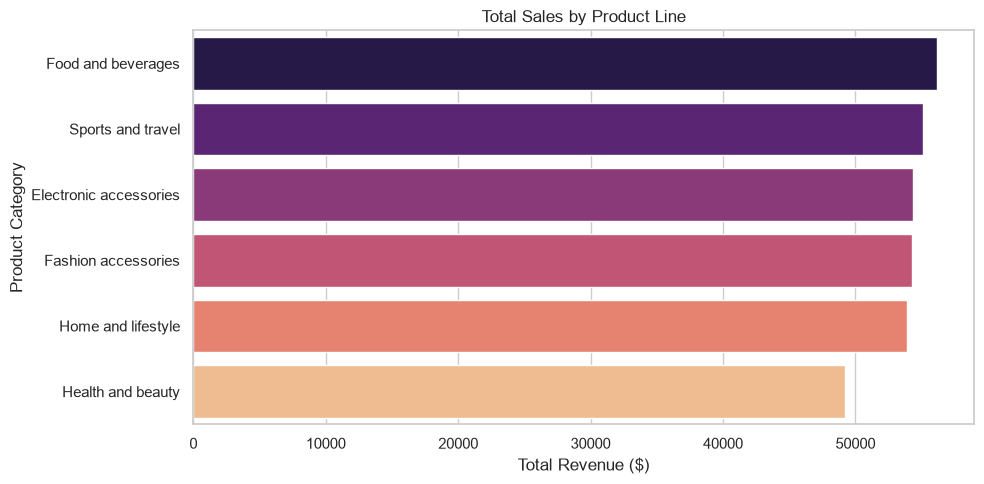

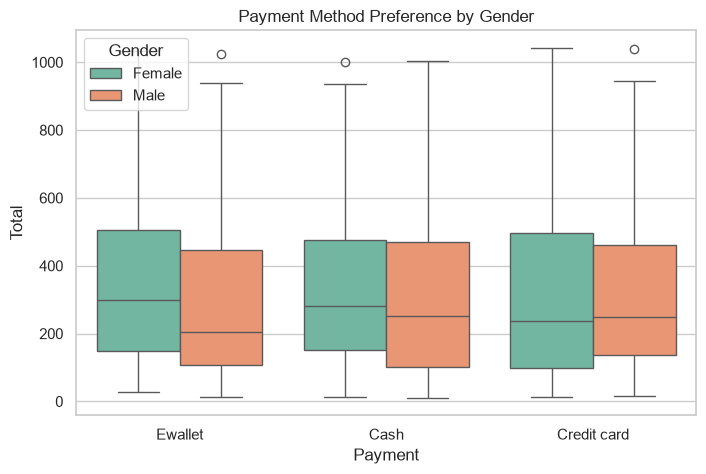

C:\Users\Admin\AppData\Local\Temp\ipykernel_5928\3870599235.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')


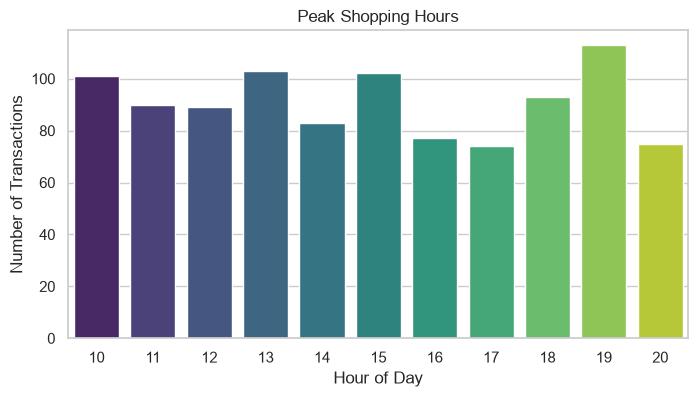

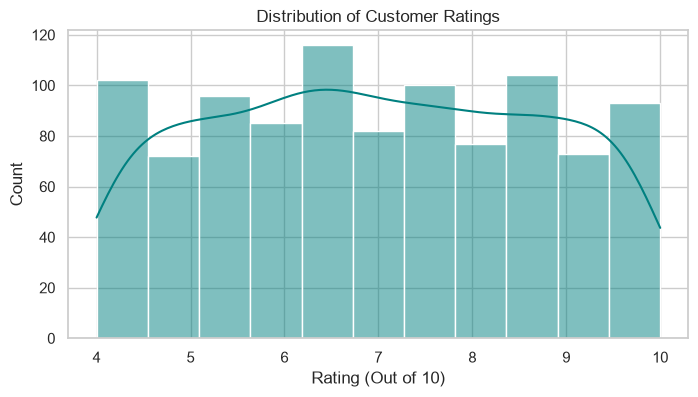

In [7]:
# 3. EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATIONS

# Chart 1: Total Sales by Product Line
plt.figure(figsize=(10, 5))
sales_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_product.values, y=sales_by_product.index, palette='magma')
plt.title('Total Sales by Product Line')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# Chart 2: Customer Gender vs Spending by Payment Method
plt.figure(figsize=(8, 5))
sns.boxplot(x='Payment', y='Total', hue='Gender', data=df, palette='Set2')
plt.title('Payment Method Preference by Gender')
plt.show()

# Chart 3: Peak Shopping Hours
plt.figure(figsize=(8, 4))
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title('Peak Shopping Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.show()

# Chart 4: Customer Satisfaction Rating Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Rating'], kde=True, color='teal')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (Out of 10)')
plt.show()

In [8]:
# 4. PREDICTIVE AI MODEL (Sales Revenue Prediction)
X = df[['Unit price', 'Quantity', 'Tax 5%']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print("R2 Score:", r2_score(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))


--- Model Evaluation ---
R2 Score: 0.9999838072902824
Root Mean Squared Error (RMSE): 1.0263925195435815
